# 📰 Online News Popularity — Regression Analysis
**Dataset**: [UCI Online News Popularity](https://archive.uci.edu/dataset/332/online+news+popularity)  
**Goal**: Predict the number of social media shares an article will receive based on its content and metadata features.

---

## 🗺️ Notebook Roadmap
| Section | What You'll Learn |
|---|---|
| 0. Setup | How to install and import the right libraries |
| 1. EDA | Understanding the data before modeling |
| 2. Assumptions Validation | Why regression needs certain conditions to work |
| 3. Train/Test Split | How to fairly evaluate a model |
| 4. Cross-Validation | How to get a more reliable performance estimate |
| 5. Hyperparameter Tuning | How to find the best model settings |
| 6. Results Validation | How to interpret and trust your final model |

---

### 🔑 Key Concept: What is Regression?
> **Regression** is a type of supervised machine learning where the goal is to predict a **continuous numeric value** (like a count of shares) rather than a category.  
> Example: Predicting that an article will get **3,241 shares** is regression. Predicting it will be "popular" or "not popular" would be *classification*.

---
## 0. Environment Setup

### 📦 Install Dependencies
Run the cell below only once (or if you get an ImportError). It installs all libraries this notebook needs.

**What each library does:**
- `ucimlrepo` — Official helper to download UCI datasets
- `pandas` — Data manipulation (think: supercharged Excel in Python)
- `numpy` — Numerical computing (math on arrays)
- `matplotlib` / `seaborn` — Data visualization
- `scikit-learn` — The core machine learning library; contains models, preprocessing, and evaluation tools
- `scipy` — Statistical tests
- `statsmodels` — Deeper statistical modeling and diagnostics

In [1]:
# ============================================================
# CELL 0-A: Install all required packages
# Run this once, then you can comment it out.
# ============================================================
# Uncomment and run if you haven't installed these yet:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels

# NOTE: ucimlrepo is NOT required to run this notebook. The dataset is loaded
# from a local CSV (data/online_news_popularity.csv), which is included in
# the repository. ucimlrepo is only needed if you want to regenerate that CSV
# yourself via fetch_data.py at the repo root.


In [2]:
# ============================================================
# CELL 0-B: Import all libraries
# ============================================================


# --- Data manipulation ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Statistics ---
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# --- Machine Learning (scikit-learn) ---
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')  # Suppress minor warnings for cleaner output

# Set a consistent visual style for all plots
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
# WHY? Machine learning has randomness (e.g. train/test splits, tree building).
# Fixing the seed ensures your results are the same every run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All imports successful!")

✅ All imports successful!


---
## 📖 Feature Dictionary

This dataset has 58 predictive features with technical names that aren't self-explanatory. Before diving into EDA, let's build a lookup dictionary mapping each column name to a plain-English description (sourced from the official [UCI dataset documentation](https://archive.ics.uci.edu/dataset/332/online+news+popularity)).

We'll use this dictionary throughout the notebook to make every chart, table, and printout self-explanatory — so you never have to guess what `kw_avg_avg` or `LDA_02` means.

In [3]:
# ============================================================
# CELL 0-C: Feature dictionary — maps column names to descriptions
# ============================================================
# Source: UCI 'OnlineNewsPopularity.names' attribute documentation
# https://archive.ics.uci.edu/dataset/332/online+news+popularity

FEATURE_DESCRIPTIONS = {
    'url': 'URL of the article (non-predictive)',
    'timedelta': 'Days between article publication and dataset acquisition (non-predictive)',
    'n_tokens_title': 'Number of words in the title',
    'n_tokens_content': 'Number of words in the content',
    'n_unique_tokens': 'Rate of unique words in the content',
    'n_non_stop_words': 'Rate of non-stop words in the content',
    'n_non_stop_unique_tokens': 'Rate of unique non-stop words in the content',
    'num_hrefs': 'Number of links',
    'num_self_hrefs': 'Number of links to other Mashable articles',
    'num_imgs': 'Number of images',
    'num_videos': 'Number of videos',
    'average_token_length': 'Average length of the words in the content',
    'num_keywords': 'Number of keywords in the article metadata',
    'data_channel_is_lifestyle': 'Is the article in the Lifestyle channel?',
    'data_channel_is_entertainment': 'Is the article in the Entertainment channel?',
    'data_channel_is_bus': 'Is the article in the Business channel?',
    'data_channel_is_socmed': 'Is the article in the Social Media channel?',
    'data_channel_is_tech': 'Is the article in the Tech channel?',
    'data_channel_is_world': 'Is the article in the World channel?',
    'kw_min_min': 'Worst keyword — minimum shares it has ever earned',
    'kw_max_min': 'Worst keyword — maximum shares it has ever earned',
    'kw_avg_min': 'Worst keyword — average shares it earns',
    'kw_min_max': 'Best keyword — minimum shares it has ever earned',
    'kw_max_max': 'Best keyword — maximum shares it has ever earned',
    'kw_avg_max': 'Best keyword — average shares it earns',
    'kw_min_avg': 'Average keyword — minimum shares it has ever earned',
    'kw_max_avg': 'Average keyword — maximum shares it has ever earned',
    'kw_avg_avg': 'Average keyword — average shares it earns',
    'self_reference_min_shares': 'Min. shares of articles referenced/linked by this one',
    'self_reference_max_shares': 'Max. shares of articles referenced/linked by this one',
    'self_reference_avg_sharess': 'Avg. shares of articles referenced/linked by this one',
    'weekday_is_monday': 'Was the article published on a Monday?',
    'weekday_is_tuesday': 'Was the article published on a Tuesday?',
    'weekday_is_wednesday': 'Was the article published on a Wednesday?',
    'weekday_is_thursday': 'Was the article published on a Thursday?',
    'weekday_is_friday': 'Was the article published on a Friday?',
    'weekday_is_saturday': 'Was the article published on a Saturday?',
    'weekday_is_sunday': 'Was the article published on a Sunday?',
    'is_weekend': 'Was the article published on a weekend?',
    'LDA_00': 'Closeness to LDA topic 0 (auto-discovered topic cluster)',
    'LDA_01': 'Closeness to LDA topic 1 (auto-discovered topic cluster)',
    'LDA_02': 'Closeness to LDA topic 2 (auto-discovered topic cluster)',
    'LDA_03': 'Closeness to LDA topic 3 (auto-discovered topic cluster)',
    'LDA_04': 'Closeness to LDA topic 4 (auto-discovered topic cluster)',
    'global_subjectivity': 'Overall text subjectivity (0=objective, 1=subjective)',
    'global_sentiment_polarity': 'Overall text sentiment polarity (negative to positive)',
    'global_rate_positive_words': 'Rate of positive words in the content',
    'global_rate_negative_words': 'Rate of negative words in the content',
    'rate_positive_words': 'Rate of positive words among non-neutral words',
    'rate_negative_words': 'Rate of negative words among non-neutral words',
    'avg_positive_polarity': 'Average polarity of positive words',
    'min_positive_polarity': 'Minimum polarity of positive words',
    'max_positive_polarity': 'Maximum polarity of positive words',
    'avg_negative_polarity': 'Average polarity of negative words',
    'min_negative_polarity': 'Minimum polarity of negative words',
    'max_negative_polarity': 'Maximum polarity of negative words',
    'title_subjectivity': 'Title subjectivity (0=objective, 1=subjective)',
    'title_sentiment_polarity': 'Title sentiment polarity (negative to positive)',
    'abs_title_subjectivity': 'Absolute subjectivity level of the title',
    'abs_title_sentiment_polarity': 'Absolute sentiment polarity level of the title',
    'shares': 'Number of times the article was shared on social media (TARGET)',
    'log_shares': 'Log-transformed number of shares: log(shares + 1) (TARGET)',
}


def describe(feature_name):
    """Return a plain-English description for a single feature name."""
    clean_name = feature_name.strip()
    return FEATURE_DESCRIPTIONS.get(clean_name, 'No description available')


def describe_features(feature_names):
    """
    Given a list of feature names, return a DataFrame with columns:
    'Feature' and 'Description'. Useful for displaying alongside
    correlation values, importance scores, VIF values, etc.
    """
    return pd.DataFrame({
        'Feature': feature_names,
        'Description': [describe(f) for f in feature_names]
    })


print(f"✅ Feature dictionary loaded: {len(FEATURE_DESCRIPTIONS)} entries")
print("\nExample lookups:")
for example_feat in ['kw_avg_avg', 'LDA_02', 'self_reference_avg_sharess', 'is_weekend']:
    print(f"  {example_feat:<30} → {describe(example_feat)}")
# Display the full dictionary as a reference table (useful to scroll through anytime)
feature_dict_df = describe_features([f for f in FEATURE_DESCRIPTIONS.keys() if f not in ['url', 'timedelta', 'shares', 'log_shares']])
print(f"\n📖 Full feature dictionary ({len(feature_dict_df)} predictive features) — scroll to browse:")
feature_dict_df

✅ Feature dictionary loaded: 62 entries

Example lookups:
  kw_avg_avg                     → Average keyword — average shares it earns
  LDA_02                         → Closeness to LDA topic 2 (auto-discovered topic cluster)
  self_reference_avg_sharess     → Avg. shares of articles referenced/linked by this one
  is_weekend                     → Was the article published on a weekend?

📖 Full feature dictionary (58 predictive features) — scroll to browse:


,Feature,Description
0,n_tokens_title,Number of words in the title
1,n_tokens_content,Number of words in the content
2,n_unique_tokens,Rate of unique words in the content
3,n_non_stop_words,Rate of non-stop words in the content
4,n_non_stop_unique_tokens,Rate of unique non-stop words in the content
5,num_hrefs,Number of links
6,num_self_hrefs,Number of links to other Mashable articles
7,num_imgs,Number of images
8,num_videos,Number of videos
9,average_token_length,Average length of the words in the content


---
## 1. Exploratory Data Analysis (EDA)

### 🔑 What is EDA and Why Does It Matter?
> **EDA (Exploratory Data Analysis)** is the process of investigating your dataset *before* building any models.  
> Think of it like reading the instruction manual before assembling furniture — you learn the shape of the data, spot problems early, and avoid wasted effort.

**What we're looking for in EDA:**
1. **Shape** — How many rows and columns?
2. **Types** — What kind of data is in each column (numbers, categories, booleans)?
3. **Missing values** — Any gaps in the data?
4. **Distributions** — Are values spread out normally, or skewed?
5. **Outliers** — Are there extreme values that could mislead the model?
6. **Correlations** — Which features move together with our target (shares)?

In [4]:
# ============================================================
# CELL 1-A: Load the dataset
# ============================================================
# This dataset is loaded from a local CSV (data/online_news_popularity.csv)
# rather than downloaded from UCI at runtime. This makes the notebook:
#   - Network-independent (no dependency on UCI's servers being reachable)
#   - Faster (no download on every run)
#   - Portable across Jupyter, VS Code, Spyder, and cloud notebook environments
#
# If data/online_news_popularity.csv is missing, run `python fetch_data.py`
# from the repo root (requires `pip install ucimlrepo` and internet access
# to archive.ics.uci.edu) to regenerate it.

print("Loading dataset from local CSV...")
df = pd.read_csv('data/online_news_popularity.csv')

# Defensive: strip column names in case the CSV was regenerated differently
df.columns = df.columns.str.strip()

print(f"✅ Dataset loaded!")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"   Last 3 columns: {list(df.columns[-3:])}  ← 'shares' should appear here")

Loading dataset from local CSV...
✅ Dataset loaded!
   Shape: 39,644 rows × 59 columns
   Memory usage: 18.7 MB
   Last 3 columns: ['abs_title_subjectivity', 'abs_title_sentiment_polarity', 'shares']  ← 'shares' should appear here


In [5]:
# ============================================================
# CELL 1-B: First look at the data
# ============================================================
# .head() shows the first 5 rows — your very first look at the raw data.
# Always do this first to catch loading errors and understand the format.

print("📋 First 5 rows of the dataset:")
df.head()

📋 First 5 rows of the dataset:


,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [6]:
# ============================================================
# CELL 1-C: Data types and non-null counts
# ============================================================
# .info() is extremely useful — it shows:
#   - Column names
#   - How many non-null (non-missing) values exist
#   - Data type of each column (int64, float64, object, etc.)
# If non-null count < total rows, you have MISSING VALUES to handle!

print("📊 Dataset Info:")
df.info()

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   n_tokens_title                 39644 non-null  float64
 1   n_tokens_content               39644 non-null  float64
 2   n_unique_tokens                39644 non-null  float64
 3   n_non_stop_words               39644 non-null  float64
 4   n_non_stop_unique_tokens       39644 non-null  float64
 5   num_hrefs                      39644 non-null  float64
 6   num_self_hrefs                 39644 non-null  float64
 7   num_imgs                       39644 non-null  float64
 8   num_videos                     39644 non-null  float64
 9   average_token_length           39644 non-null  float64
 10  num_keywords                   39644 non-null  float64
 11  data_channel_is_lifestyle      39644 non-null  float64
 12  data_channel_is_entertainment  39644 non-

In [7]:
# ============================================================
# CELL 1-D: Statistical summary
# ============================================================
# .describe() gives you 8 statistics per column:
#   count  = number of non-missing values
#   mean   = average value
#   std    = standard deviation (spread from mean)
#   min    = smallest value
#   25%    = 25th percentile (bottom quarter)
#   50%    = median (middle value)
#   75%    = 75th percentile (top quarter)
#   max    = largest value
#
# Look for: max >> 75% (outliers), mean >> median (skewness)

print("📈 Statistical Summary:")
df.describe().T.round(2)  # .T transposes so columns are rows — easier to read with 60 features

📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
n_tokens_title,39644.0,10.40,2.11,2.00,9.00,10.00,12.00,23.00
n_tokens_content,39644.0,546.51,471.11,0.00,246.00,409.00,716.00,8474.00
n_unique_tokens,39644.0,0.55,3.52,0.00,0.47,0.54,0.61,701.00
n_non_stop_words,39644.0,1.00,5.23,0.00,1.00,1.00,1.00,1042.00
n_non_stop_unique_tokens,39644.0,0.69,3.26,0.00,0.63,0.69,0.75,650.00
num_hrefs,39644.0,10.88,11.33,0.00,4.00,8.00,14.00,304.00
num_self_hrefs,39644.0,3.29,3.86,0.00,1.00,3.00,4.00,116.00
num_imgs,39644.0,4.54,8.31,0.00,1.00,1.00,4.00,128.00
num_videos,39644.0,1.25,4.11,0.00,0.00,0.00,1.00,91.00
average_token_length,39644.0,4.55,0.84,0.00,4.48,4.66,4.85,8.04


In [8]:
# ============================================================
# CELL 1-E: Missing values check
# ============================================================
# Missing values (NaN) can crash your model or silently distort results.
# ALWAYS check for them before proceeding.

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("✅ No missing values found! (This is unusual and lucky — UCI cleaned this for us.)")
else:
    print(f"⚠️ Found missing values in {len(missing_df)} columns:")
    print(missing_df)

✅ No missing values found! (This is unusual and lucky — UCI cleaned this for us.)


🎯 Target Variable: 'shares'
   Mean:    3,395
   Median:  1,400
   Std Dev: 11,627
   Min:     1
   Max:     843,300
   Skewness: 33.96  (>1 = right-skewed, <-1 = left-skewed)
   Kurtosis: 1832.67  (>3 = heavy tails / extreme outliers)


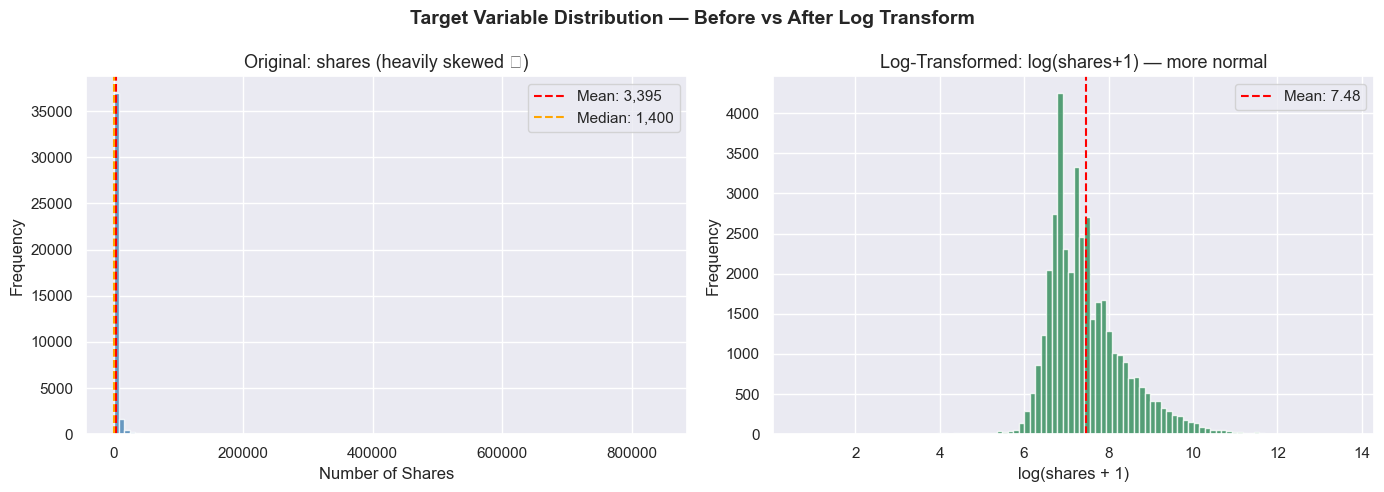


💡 Insight: The original 'shares' distribution is heavily RIGHT-SKEWED.
   This means a few articles go viral (millions of shares) while most get few.
   We'll use log(shares+1) as our target to normalize it for linear regression.


In [9]:
# ============================================================
# CELL 1-F: Target variable analysis — 'shares'
# ============================================================
# The target variable is what we're predicting: 'shares'
# Understanding its distribution is critical — it tells us:
#   - Whether to log-transform it (if heavily skewed)
#   - The realistic range of predictions
#   - Whether outliers will distort the model

target = df['shares']

print("🎯 Target Variable: 'shares'")
print(f"   Mean:    {target.mean():,.0f}")
print(f"   Median:  {target.median():,.0f}")
print(f"   Std Dev: {target.std():,.0f}")
print(f"   Min:     {target.min():,.0f}")
print(f"   Max:     {target.max():,.0f}")
print(f"   Skewness: {target.skew():.2f}  (>1 = right-skewed, <-1 = left-skewed)")
print(f"   Kurtosis: {target.kurtosis():.2f}  (>3 = heavy tails / extreme outliers)")

# --- Plot original vs log-transformed target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original distribution
axes[0].hist(target, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Original: shares (heavily skewed ➡)', fontsize=13)
axes[0].set_xlabel('Number of Shares')
axes[0].set_ylabel('Frequency')
axes[0].axvline(target.mean(), color='red', linestyle='--', label=f'Mean: {target.mean():,.0f}')
axes[0].axvline(target.median(), color='orange', linestyle='--', label=f'Median: {target.median():,.0f}')
axes[0].legend()

# Log-transformed distribution
log_target = np.log1p(target)  # log1p = log(1+x), handles zero values safely
axes[1].hist(log_target, bins=100, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed: log(shares+1) — more normal', fontsize=13)
axes[1].set_xlabel('log(shares + 1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(log_target.mean(), color='red', linestyle='--', label=f'Mean: {log_target.mean():.2f}')
axes[1].legend()

plt.suptitle('Target Variable Distribution — Before vs After Log Transform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Insight: The original 'shares' distribution is heavily RIGHT-SKEWED.")
print("   This means a few articles go viral (millions of shares) while most get few.")
print("   We'll use log(shares+1) as our target to normalize it for linear regression.")

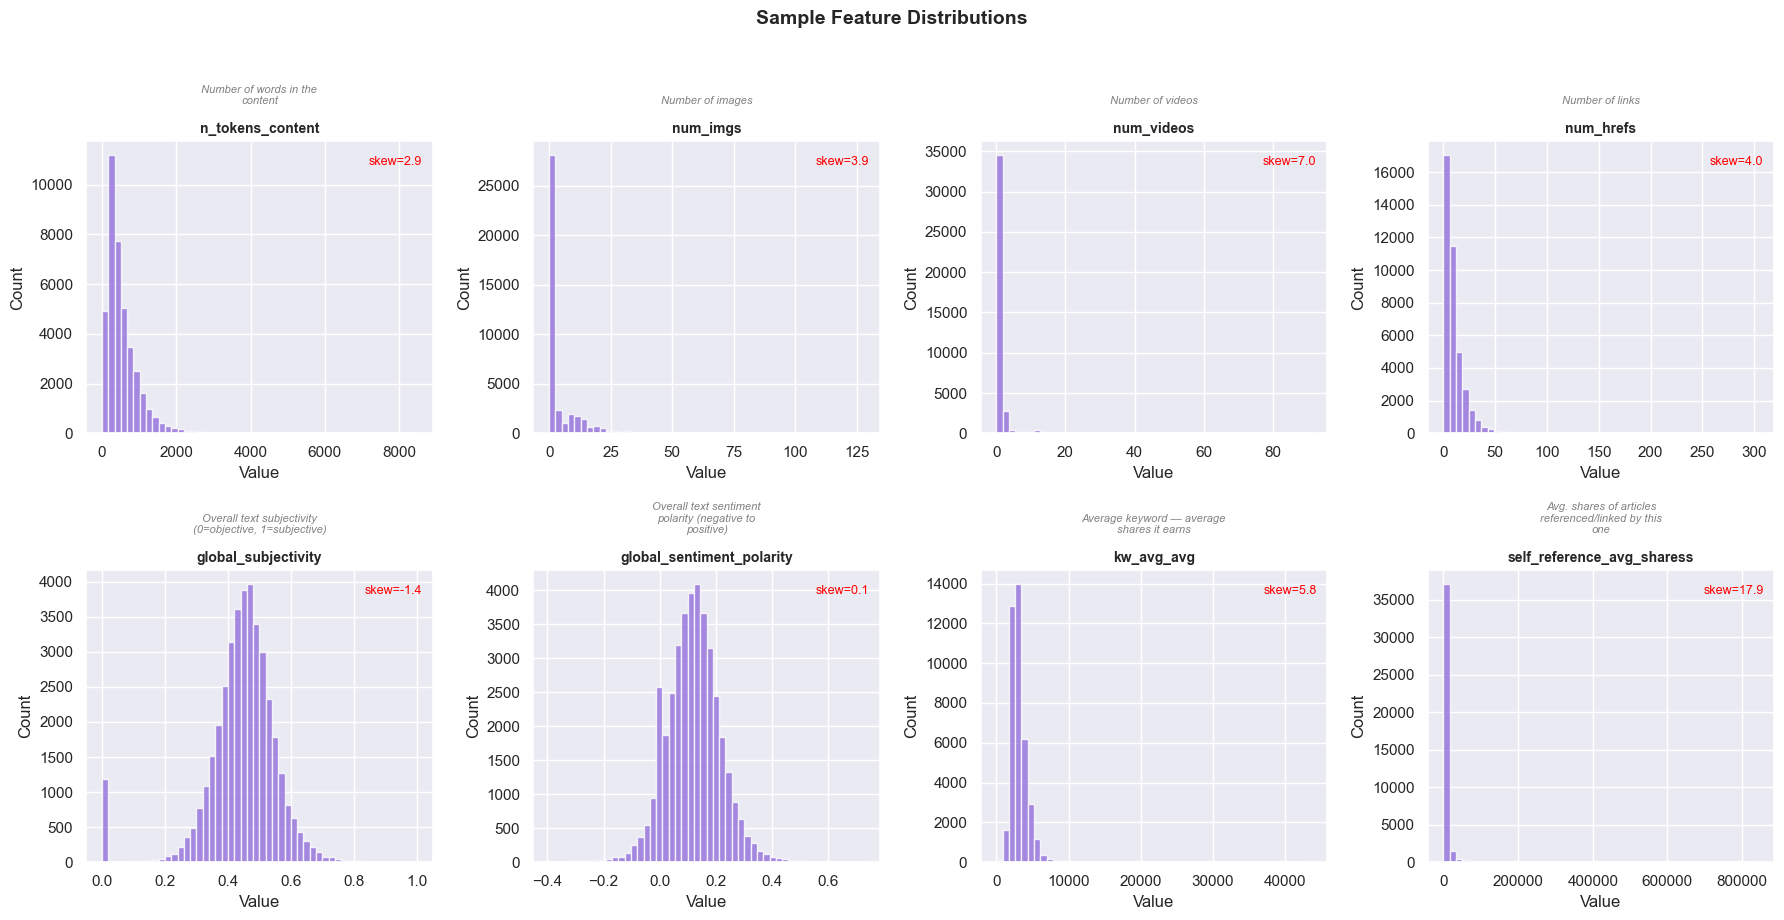

💡 Many features are right-skewed (long tail to the right).
   Linear regression performs better when features are closer to normal distributions.

📋 Feature reference:
                   Feature                                            Description
          n_tokens_content                         Number of words in the content
                  num_imgs                                       Number of images
                num_videos                                       Number of videos
                 num_hrefs                                        Number of links
       global_subjectivity  Overall text subjectivity (0=objective, 1=subjective)
 global_sentiment_polarity Overall text sentiment polarity (negative to positive)
                kw_avg_avg              Average keyword — average shares it earns
self_reference_avg_sharess  Avg. shares of articles referenced/linked by this one


In [10]:
# ============================================================
# CELL 1-G: Feature distributions — sample of key features
# ============================================================
# We can't plot all 58 features, so we pick a representative sample.
# This helps us spot:
#   - Skewed features that may need transformation
#   - Binary features (0/1) that behave differently
#   - Constant or near-constant features (useless for prediction)

sample_features = [
    'n_tokens_content',    # Article length
    'num_imgs',            # Number of images
    'num_videos',          # Number of videos
    'num_hrefs',           # Number of links
    'global_subjectivity', # Subjectivity score
    'global_sentiment_polarity',  # Sentiment score
    'kw_avg_avg',          # Keyword average shares
    'self_reference_avg_sharess',  # Referenced article shares
]

import textwrap

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(sample_features):
    axes[i].hist(df[feat], bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
    # Title: technical column name (bold)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    # Subtitle: plain-English description, wrapped to fit
    wrapped_desc = '\n'.join(textwrap.wrap(describe(feat), width=28))
    axes[i].text(0.5, 1.12, wrapped_desc, transform=axes[i].transAxes,
                 ha='center', va='bottom', fontsize=8, color='gray', style='italic')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    skew_val = df[feat].skew()
    axes[i].text(0.97, 0.95, f'skew={skew_val:.1f}', transform=axes[i].transAxes,
                 ha='right', va='top', fontsize=9, color='red')

plt.suptitle('Sample Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("💡 Many features are right-skewed (long tail to the right).")
print("   Linear regression performs better when features are closer to normal distributions.")

# Reference table for the features shown above
print("\n📋 Feature reference:")
print(describe_features(sample_features).to_string(index=False))

In [11]:
# ============================================================
# CELL 1-H: Outlier detection using IQR
# ============================================================
# WHAT IS AN OUTLIER?
# An outlier is a data point that is abnormally far from most other values.
# In regression, extreme outliers can dominate the model and pull the line
# of best fit toward them, hurting predictions on normal data.
#
# IQR METHOD:
#   - IQR = Q3 - Q1  (Interquartile Range: the middle 50% of data)
#   - Lower fence = Q1 - 1.5 * IQR
#   - Upper fence = Q3 + 1.5 * IQR
#   - Anything outside these fences = outlier

def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

# Check outliers for key continuous features
continuous_features = [
    'n_tokens_content', 'num_imgs', 'num_videos', 'num_hrefs',
    'kw_avg_avg', 'self_reference_avg_sharess', 'shares'
]

outlier_data = []
for col in continuous_features:
    n_out = count_outliers_iqr(df[col])
    pct = n_out / len(df) * 100
    outlier_data.append({'Feature': col, 'Outlier Count': n_out, 'Outlier %': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_data).sort_values('Outlier %', ascending=False)
print("🔍 Outlier counts (IQR method):")
print(outlier_df.to_string(index=False))

print("\n💡 'shares' has many outliers — viral articles with millions of shares.")
print("   Strategy: use log transform to reduce their impact.")

🔍 Outlier counts (IQR method):
                   Feature  Outlier Count  Outlier %
                  num_imgs           7703      19.43
                    shares           4541      11.45
self_reference_avg_sharess           4209      10.62
                num_videos           2946       7.43
                 num_hrefs           2169       5.47
          n_tokens_content           1933       4.88
                kw_avg_avg           1629       4.11

💡 'shares' has many outliers — viral articles with millions of shares.
   Strategy: use log transform to reduce their impact.


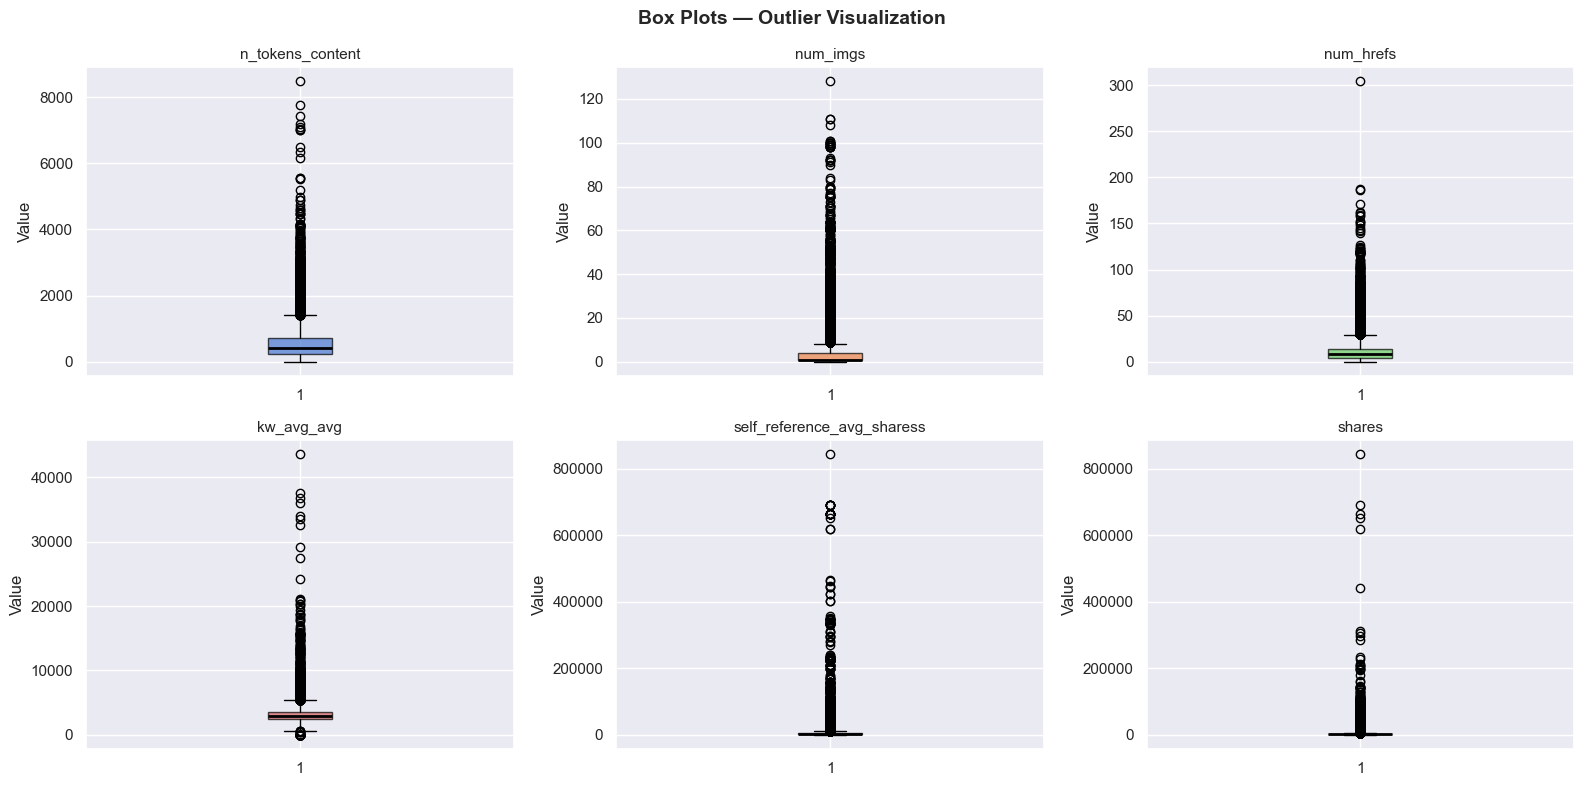

In [12]:
# ============================================================
# CELL 1-I: Box plots for top features
# ============================================================
# Box plots visually show the spread of a variable and its outliers.
#   - Box = middle 50% of data (Q1 to Q3)
#   - Line in box = median
#   - Whiskers = range within 1.5 * IQR
#   - Dots beyond whiskers = outliers

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

box_features = ['n_tokens_content', 'num_imgs', 'num_hrefs', 'kw_avg_avg', 'self_reference_avg_sharess', 'shares']
colors = sns.color_palette('muted', 6)

for i, feat in enumerate(box_features):
    axes[i].boxplot(df[feat], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🔗 Top 15 features most correlated with log(shares):

  + kw_avg_avg                       +0.2218  ████████
      └─ Average keyword — average shares it earns
  - LDA_02                           -0.1651  ██████
      └─ Closeness to LDA topic 2 (auto-discovered topic cluster)
  - data_channel_is_world            -0.1517  ██████
      └─ Is the article in the World channel?
  + LDA_03                           +0.1260  █████
      └─ Closeness to LDA topic 3 (auto-discovered topic cluster)
  + is_weekend                       +0.1144  ████
      └─ Was the article published on a weekend?
  + kw_max_avg                       +0.1093  ████
      └─ Average keyword — maximum shares it has ever earned
  + kw_min_avg                       +0.1088  ████
      └─ Average keyword — minimum shares it has ever earned
  + num_hrefs                        +0.1051  ████
      └─ Number of links
  + num_imgs                         +0.0915  ███
      └─ Number of images
  + self_reference_avg_shares

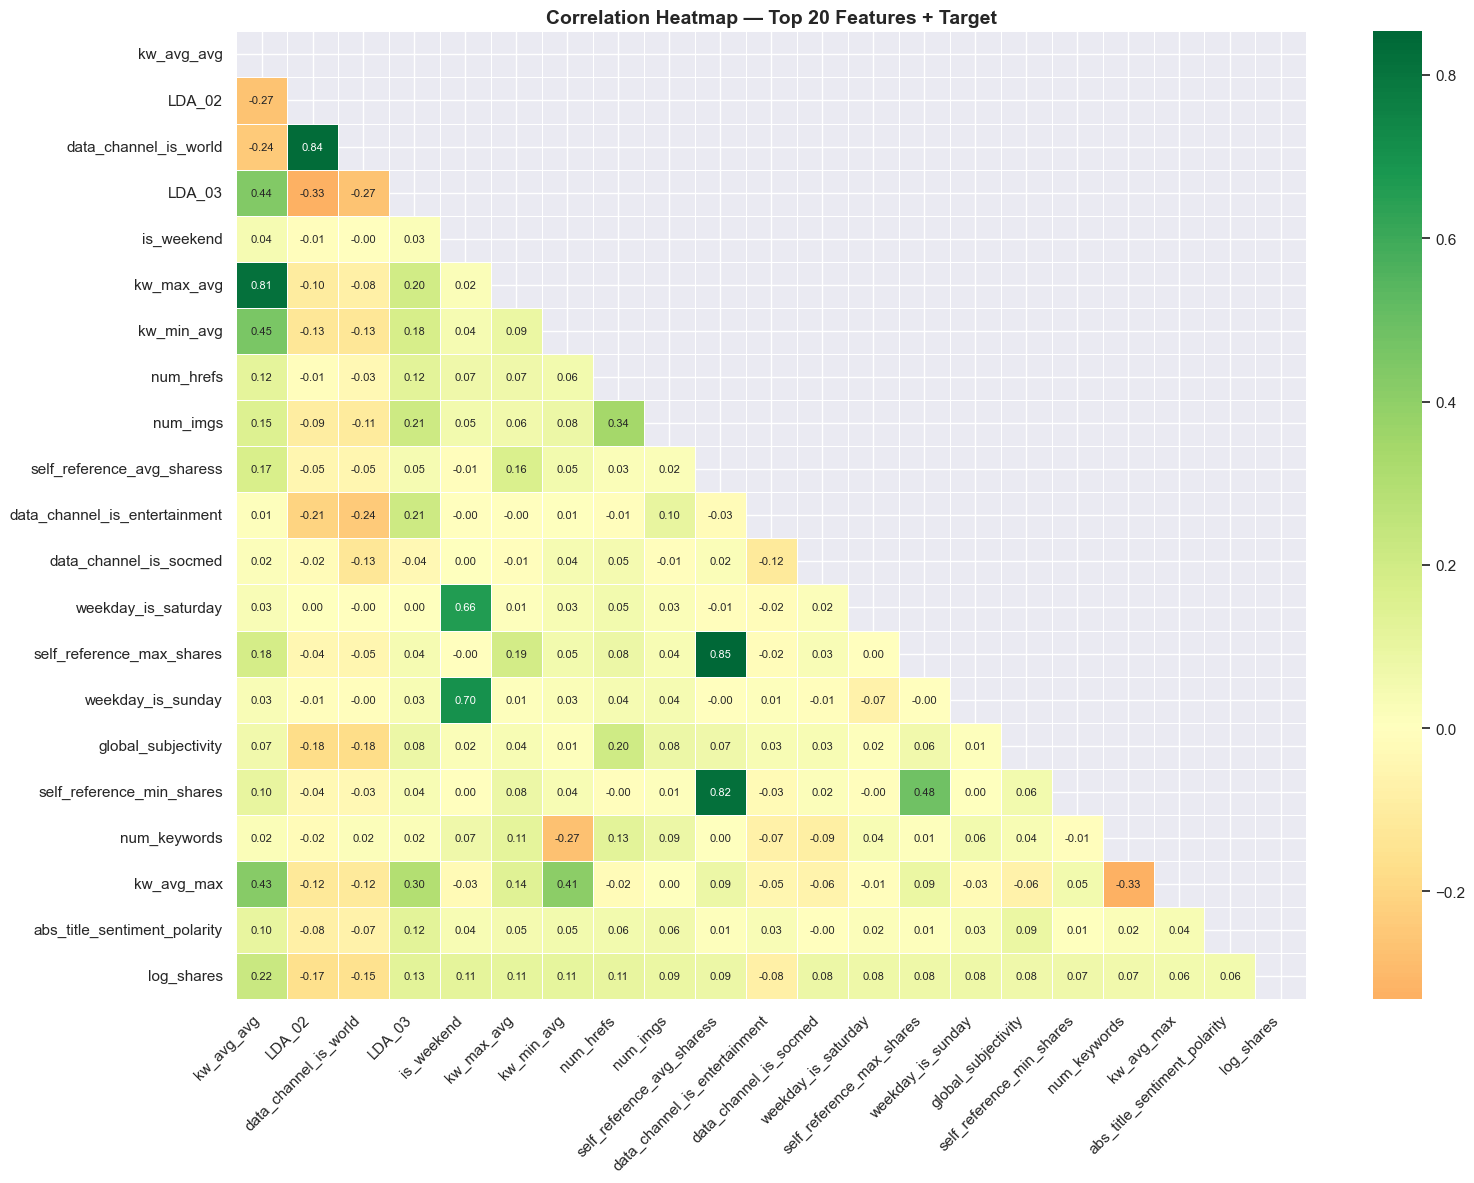

In [13]:
# ============================================================
# CELL 1-J: Correlation heatmap
# ============================================================
# WHAT IS CORRELATION?
# Correlation measures the linear relationship between two variables.
#   - +1.0 = perfect positive correlation (both go up together)
#   -  0.0 = no linear relationship
#   - -1.0 = perfect negative correlation (one goes up, other goes down)
#
# WHY IT MATTERS:
#   - Features correlated with 'shares' are likely good predictors
#   - Features highly correlated WITH EACH OTHER (multicollinearity)
#     can confuse linear regression (we check this properly in Section 2)

# Use log-shares for clearer correlation signal
df['log_shares'] = np.log1p(df['shares'])

# Compute correlations with log_shares and sort by absolute value
corr_with_target = df.drop(columns=['shares']).corr()['log_shares'].drop('log_shares')
corr_sorted = corr_with_target.abs().sort_values(ascending=False)

print("🔗 Top 15 features most correlated with log(shares):\n")
top15_corr = corr_with_target[corr_sorted.head(15).index]
for feat, corr in top15_corr.items():
    bar = '█' * int(abs(corr) * 40)
    direction = '+' if corr > 0 else '-'
    print(f"  {direction} {feat:<32} {corr:+.4f}  {bar}")
    print(f"      \u2514\u2500 {describe(feat)}")

# Display the same data as a clean reference table with descriptions
top15_table = describe_features(top15_corr.index)
top15_table.insert(1, 'Correlation', top15_corr.values.round(4))
print("\n📋 Reference table — feature, correlation, and meaning:")
print(top15_table.to_string(index=False))

# Heatmap of top 20 features + target
top20_features = list(corr_sorted.head(20).index) + ['log_shares']
corr_matrix = df[top20_features].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 20 Features + Target', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

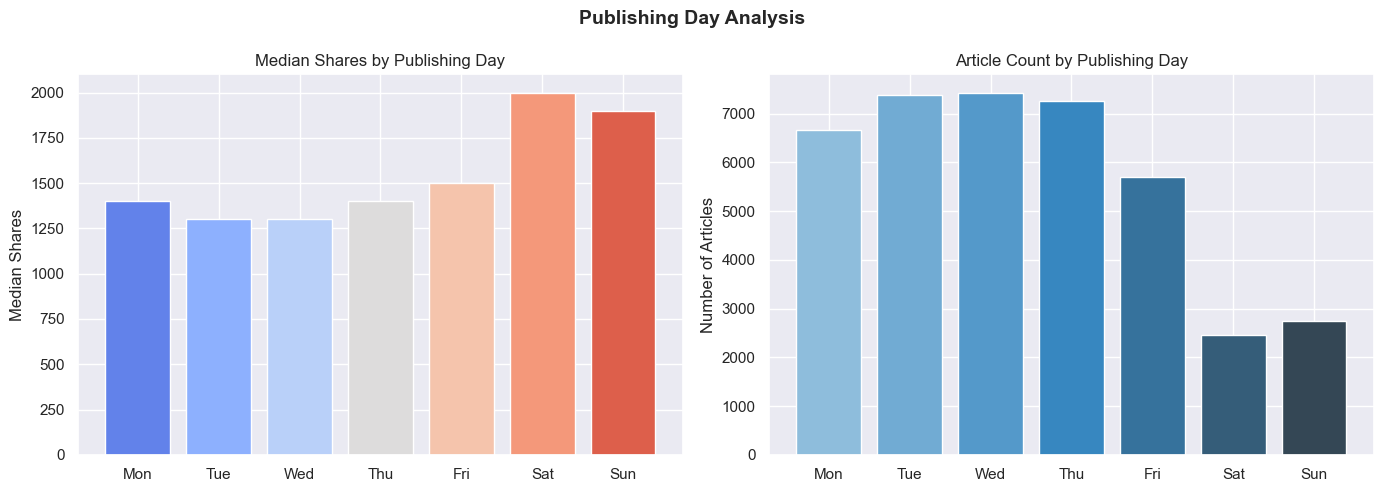

In [14]:
# ============================================================
# CELL 1-K: Publishing day analysis
# ============================================================
# The dataset has binary columns indicating what day an article was published.
# This cell visualizes whether publishing day affects share counts.

day_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
            'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday']
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

avg_shares_by_day = []
count_by_day = []
for col in day_cols:
    mask = df[col] == 1
    avg_shares_by_day.append(df.loc[mask, 'shares'].median())
    count_by_day.append(mask.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_names, avg_shares_by_day, color=sns.color_palette('coolwarm', 7), edgecolor='white')
axes[0].set_title('Median Shares by Publishing Day', fontsize=12)
axes[0].set_ylabel('Median Shares')

axes[1].bar(day_names, count_by_day, color=sns.color_palette('Blues_d', 7), edgecolor='white')
axes[1].set_title('Article Count by Publishing Day', fontsize=12)
axes[1].set_ylabel('Number of Articles')

plt.suptitle('Publishing Day Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

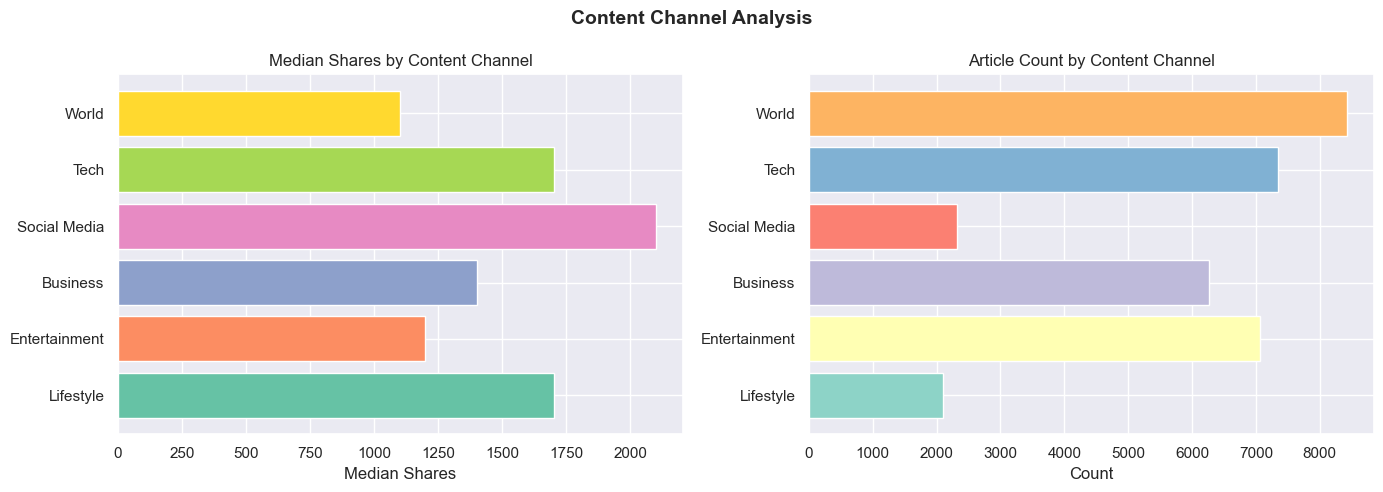


📊 EDA Summary:
   ✅ No missing values
   ⚠️  Target 'shares' is heavily right-skewed — will log-transform
   ⚠️  Many features are skewed — may need scaling/transformation
   📌 Social Media articles tend to get the most shares
   📌 Weekend articles have higher median shares but fewer total articles


In [15]:
# ============================================================
# CELL 1-L: Content channel analysis
# ============================================================
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment',
                'data_channel_is_bus', 'data_channel_is_socmed',
                'data_channel_is_tech', 'data_channel_is_world']
channel_names = ['Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World']

median_shares = [df.loc[df[col] == 1, 'shares'].median() for col in channel_cols]
counts = [df[col].sum() for col in channel_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(channel_names, median_shares, color=sns.color_palette('Set2', 6))
axes[0].set_title('Median Shares by Content Channel', fontsize=12)
axes[0].set_xlabel('Median Shares')

axes[1].barh(channel_names, counts, color=sns.color_palette('Set3', 6))
axes[1].set_title('Article Count by Content Channel', fontsize=12)
axes[1].set_xlabel('Count')

plt.suptitle('Content Channel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 EDA Summary:")
print("   ✅ No missing values")
print("   ⚠️  Target 'shares' is heavily right-skewed — will log-transform")
print("   ⚠️  Many features are skewed — may need scaling/transformation")
print("   📌 Social Media articles tend to get the most shares")
print("   📌 Weekend articles have higher median shares but fewer total articles")

---
## 2. Assumptions Validation

### 🔑 Why Does Regression Have Assumptions?
> Linear regression is built on mathematical theory that only *guarantees* good results when certain conditions (assumptions) hold.  
> If you skip this step, your model might work, but you won't know *why* it fails or how to improve it.

**The 5 key assumptions of Linear Regression:**

| # | Assumption | What it means |
|---|---|---|
| 1 | **Linearity** | The relationship between features and target is linear |
| 2 | **Independence** | Each observation is independent (not sequential/time-related) |
| 3 | **Homoscedasticity** | The spread of errors (residuals) is constant across predictions |
| 4 | **Normality of Residuals** | The errors are normally distributed |
| 5 | **No Multicollinearity** | Features aren't highly correlated with each other |

In [16]:
# ============================================================
# CELL 2-A: Data preparation for assumption checks
# ============================================================
# Before checking assumptions, we need to:
# 1. Apply the log transform to shares
# 2. Drop non-predictive columns (url, timedelta)
# 3. Fit a baseline linear regression

# Drop non-predictive ID columns
feature_cols = [c for c in df.columns if c not in ['url', 'timedelta', 'shares', 'log_shares']]
X_clean = df[feature_cols].copy()
y_log = df['log_shares'].copy()

# Scale features — Linear regression is sensitive to feature magnitude.
# StandardScaler converts each feature to mean=0, std=1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# Fit a baseline OLS (Ordinary Least Squares) model using statsmodels
# We add a constant (intercept) manually — statsmodels doesn't add it automatically
X_with_const = sm.add_constant(X_scaled)
ols_model = sm.OLS(y_log, X_with_const).fit()

# Residuals = actual values - predicted values
# A good model has residuals randomly scattered around 0 with no pattern.
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid

print(f"✅ Baseline OLS model fitted on {len(y_log):,} observations")
print(f"   R² = {ols_model.rsquared:.4f}  (explains {ols_model.rsquared*100:.1f}% of variance)")
print(f"   Adj. R² = {ols_model.rsquared_adj:.4f}")

✅ Baseline OLS model fitted on 39,644 observations
   R² = 0.1269  (explains 12.7% of variance)
   Adj. R² = 0.1257


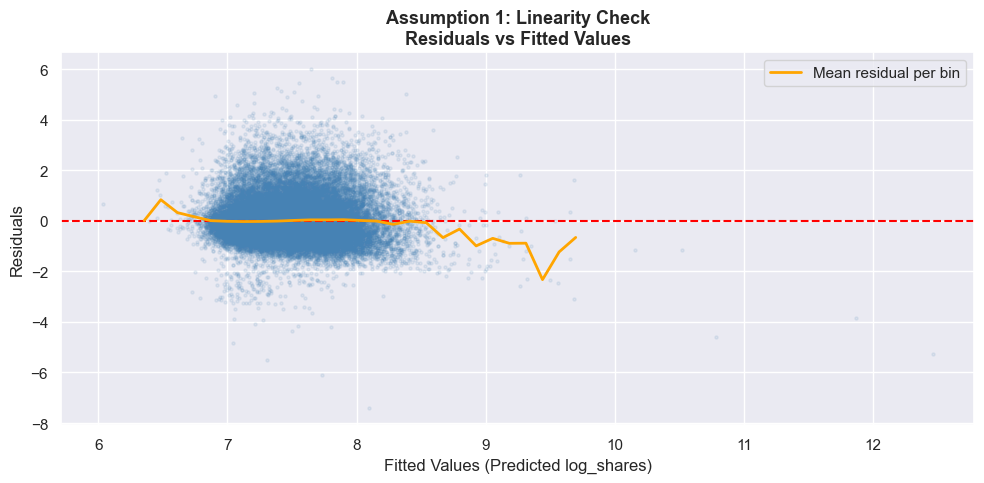

💡 If the orange line is roughly flat at 0, linearity assumption is reasonably satisfied.


In [17]:
# ============================================================
# CELL 2-B: Assumption 1 — Linearity
# CHECK: Residuals vs Fitted Values plot
# ============================================================
# If the relationship is linear, residuals should scatter randomly
# around the horizontal line at 0 — no curve, no fan shape.
#
# WHAT TO LOOK FOR:
#   ✅ Good: Random scatter around 0
#   ❌ Bad: U-shape or curve (non-linear relationship exists)

plt.figure(figsize=(10, 5))
plt.scatter(fitted_values, residuals, alpha=0.1, s=5, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Fitted Values (Predicted log_shares)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Assumption 1: Linearity Check\nResiduals vs Fitted Values', fontsize=13, fontweight='bold')

# Add a LOESS smooth curve to see the trend
from scipy.stats import binned_statistic
bins = 50
bin_means, bin_edges, _ = binned_statistic(fitted_values, residuals, statistic='mean', bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.plot(bin_centers, bin_means, color='orange', linewidth=2, label='Mean residual per bin')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 If the orange line is roughly flat at 0, linearity assumption is reasonably satisfied.")

🔬 Breusch-Pagan Test for Homoscedasticity:
   LM Statistic: 1434.3182
   p-value:      1.0768e-261
   ❌ RESULT: Heteroscedasticity detected (p < 0.05)
   → Fix: Use regularized regression (Ridge/Lasso) or robust standard errors


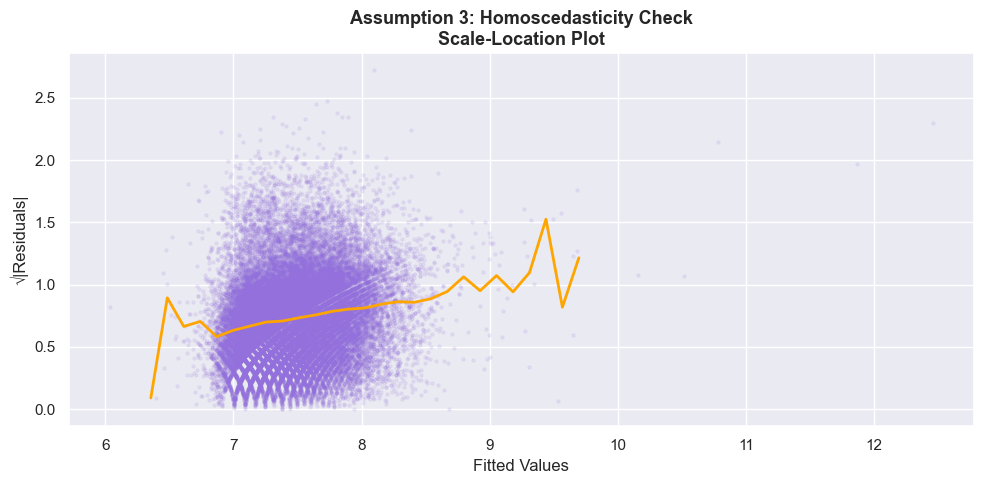

In [18]:
# ============================================================
# CELL 2-C: Assumption 3 — Homoscedasticity
# CHECK: Spread-Location plot (Scale-Location)
# ============================================================
# HOMOSCEDASTICITY means the variance of residuals is CONSTANT across
# all predicted values. The opposite is HETEROSCEDASTICITY (variance changes).
#
# Heteroscedasticity doesn't break the model but makes standard errors
# unreliable — confidence intervals and p-values become untrustworthy.
#
# We also run the Breusch-Pagan test:
#   H0: Residuals have constant variance (homoscedastic)
#   If p < 0.05, we REJECT H0 → heteroscedasticity exists

from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X_with_const)
print("🔬 Breusch-Pagan Test for Homoscedasticity:")
print(f"   LM Statistic: {bp_test[0]:.4f}")
print(f"   p-value:      {bp_test[1]:.4e}")
if bp_test[1] < 0.05:
    print("   ❌ RESULT: Heteroscedasticity detected (p < 0.05)")
    print("   → Fix: Use regularized regression (Ridge/Lasso) or robust standard errors")
else:
    print("   ✅ RESULT: No significant heteroscedasticity (p >= 0.05)")

# Scale-Location Plot
plt.figure(figsize=(10, 5))
sqrt_abs_resid = np.sqrt(np.abs(residuals))
plt.scatter(fitted_values, sqrt_abs_resid, alpha=0.1, s=5, color='mediumpurple')
plt.xlabel('Fitted Values', fontsize=12)
plt.ylabel('√|Residuals|', fontsize=12)
plt.title('Assumption 3: Homoscedasticity Check\nScale-Location Plot', fontsize=13, fontweight='bold')

bin_means2, bin_edges2, _ = binned_statistic(fitted_values, sqrt_abs_resid, statistic='mean', bins=50)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
plt.plot(bin_centers2, bin_means2, color='orange', linewidth=2)
plt.tight_layout()
plt.show()

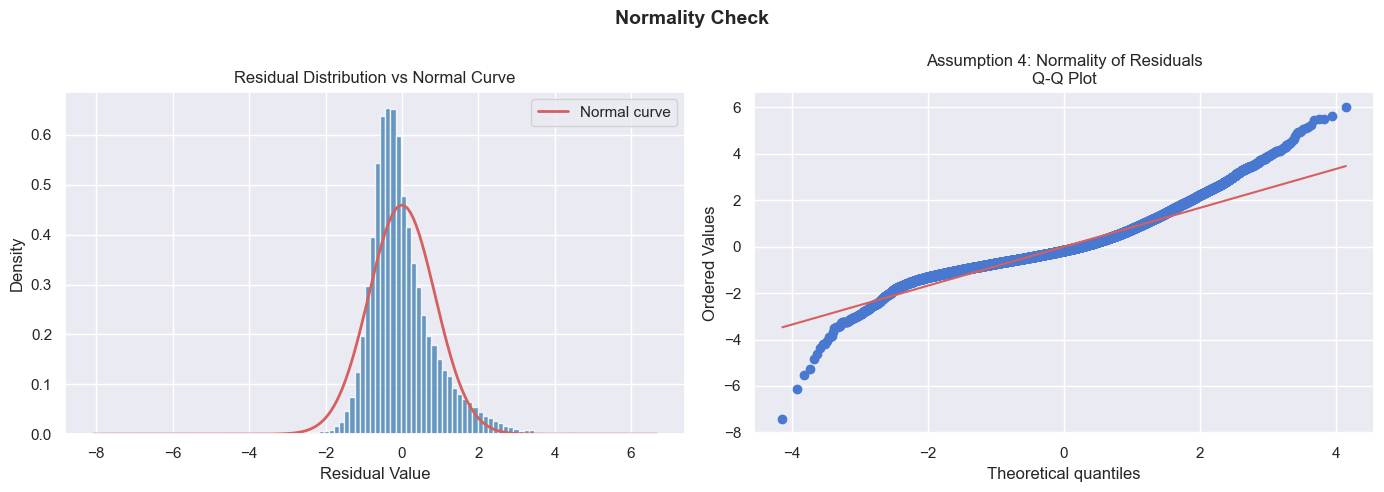

🔬 Jarque-Bera Normality Test:
   Statistic: 19856.32
   p-value:   0.0000e+00
   Skewness:  0.9982
   Kurtosis:  2.8347
   ⚠️  Residuals are NOT perfectly normal — but with 39K observations, some deviation is expected.
   → Central Limit Theorem ensures regression estimates are still approximately valid.


In [19]:
# ============================================================
# CELL 2-D: Assumption 4 — Normality of Residuals
# CHECK: Histogram + Q-Q Plot + Shapiro-Wilk test
# ============================================================
# Linear regression assumes residuals follow a NORMAL (bell-curve) distribution.
# Violations mean your confidence intervals and p-values may be wrong.
#
# Q-Q PLOT (Quantile-Quantile):
#   - If residuals are normal, points will lie on the diagonal line
#   - Deviations at tails indicate heavy tails (kurtosis) or skew

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of residuals
axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8, density=True)
xmin, xmax = axes[0].get_xlim()
x_range = np.linspace(xmin, xmax, 200)
axes[0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal curve')
axes[0].set_title('Residual Distribution vs Normal Curve', fontsize=12)
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Assumption 4: Normality of Residuals\nQ-Q Plot', fontsize=12)

plt.suptitle('Normality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Jarque-Bera test (better for large samples than Shapiro-Wilk)
jb_result = stats.jarque_bera(residuals)
jb_stat, jb_p = jb_result.statistic, jb_result.pvalue
jb_skew = stats.skew(residuals)
jb_kurt = stats.kurtosis(residuals)
print("🔬 Jarque-Bera Normality Test:")
print(f"   Statistic: {jb_stat:.2f}")
print(f"   p-value:   {jb_p:.4e}")
print(f"   Skewness:  {jb_skew:.4f}")
print(f"   Kurtosis:  {jb_kurt:.4f}")
if jb_p < 0.05:
    print("   ⚠️  Residuals are NOT perfectly normal — but with 39K observations, some deviation is expected.")
    print("   → Central Limit Theorem ensures regression estimates are still approximately valid.")

🔬 Computing VIF for all features...

Features with VIF > 5 (multicollinearity concern):
                   Feature          VIF                                              Description
       weekday_is_thursday          inf                 Was the article published on a Thursday?
         weekday_is_monday          inf                   Was the article published on a Monday?
       weekday_is_saturday          inf                 Was the article published on a Saturday?
         weekday_is_sunday          inf                   Was the article published on a Sunday?
                is_weekend          inf                  Was the article published on a weekend?
         weekday_is_friday          inf                   Was the article published on a Friday?
        weekday_is_tuesday          inf                  Was the article published on a Tuesday?
      weekday_is_wednesday          inf                Was the article published on a Wednesday?
                    LDA_03 418414263.82

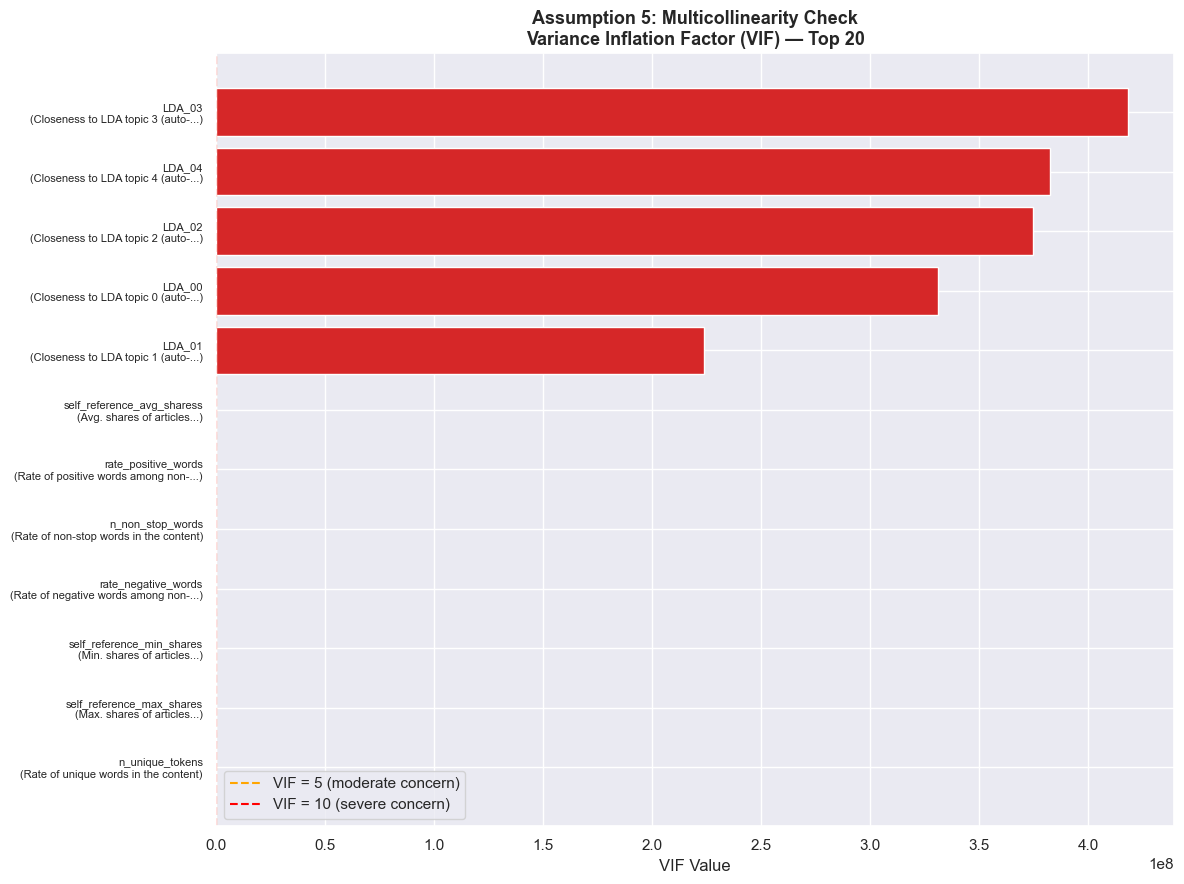


💡 High VIF features should be monitored.
   → Fix: Use Ridge/Lasso regression (regularization handles multicollinearity well)


In [20]:
# ============================================================
# CELL 2-E: Assumption 5 — No Multicollinearity (VIF)
# ============================================================
# MULTICOLLINEARITY = two or more features are highly correlated with each other.
# When this happens, linear regression can't separate their individual effects,
# leading to unstable coefficients and misleading importance estimates.
#
# VIF (Variance Inflation Factor) measures how much a feature's variance
# is inflated due to correlation with others:
#   VIF = 1      → No multicollinearity
#   VIF = 1–5    → Moderate (acceptable)
#   VIF > 5      → High multicollinearity (problem)
#   VIF > 10     → Severe multicollinearity (must address)

print("🔬 Computing VIF for all features...")

# Use a sample for speed (VIF is compute-heavy with 60 features)
X_vif_sample = pd.DataFrame(X_scaled, columns=feature_cols).sample(5000, random_state=RANDOM_STATE)

vif_data = []
for i, col in enumerate(feature_cols):
    vif = variance_inflation_factor(X_vif_sample.values, i)
    vif_data.append({'Feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
vif_df['Description'] = vif_df['Feature'].apply(describe)

high_vif = vif_df[vif_df['VIF'] > 5]
print(f"\nFeatures with VIF > 5 (multicollinearity concern):")
print(high_vif.to_string(index=False))

# Visualize top 20 VIF values
top20_vif = vif_df.head(20).copy()

# Build readable y-axis labels: 'feature_name' on top, short description below
import textwrap
ylabels = [f"{f}\n({textwrap.shorten(d, width=38, placeholder='...')})"
           for f, d in zip(top20_vif['Feature'], top20_vif['Description'])]

plt.figure(figsize=(12, 9))
colors = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c' for v in top20_vif['VIF']]
plt.barh(ylabels[::-1], top20_vif['VIF'][::-1], color=colors[::-1])
plt.axvline(5, color='orange', linestyle='--', label='VIF = 5 (moderate concern)')
plt.axvline(10, color='red', linestyle='--', label='VIF = 10 (severe concern)')
plt.xlabel('VIF Value')
plt.yticks(fontsize=8)
plt.title('Assumption 5: Multicollinearity Check\nVariance Inflation Factor (VIF) — Top 20', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("\n💡 High VIF features should be monitored.")
print("   → Fix: Use Ridge/Lasso regression (regularization handles multicollinearity well)")

In [21]:
# ============================================================
# CELL 2-F: Assumption 2 — Independence (Durbin-Watson)
# ============================================================
# The Durbin-Watson test checks for autocorrelation in residuals.
# AUTOCORRELATION = residual at time t is correlated with residual at t-1.
# This matters more for time-series data, but we check it anyway.
#
# DW statistic range:
#   ~2.0  → No autocorrelation ✅
#   < 1.5 → Positive autocorrelation ⚠️
#   > 2.5 → Negative autocorrelation ⚠️

dw_stat = durbin_watson(residuals)
print(f"🔬 Durbin-Watson Statistic: {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("   ✅ No significant autocorrelation in residuals (DW ≈ 2)")
elif dw_stat < 1.5:
    print("   ⚠️  Positive autocorrelation detected (DW < 1.5)")
else:
    print("   ⚠️  Negative autocorrelation detected (DW > 2.5)")

print("\n" + "="*60)
print("📋 ASSUMPTIONS VALIDATION SUMMARY")
print("="*60)
print("  1. Linearity:           Check residuals vs fitted plot")
print("  2. Independence:        Durbin-Watson ≈ 2.0 → OK")
print("  3. Homoscedasticity:    B-P test likely detects heteroscedasticity")
print("                          → Use regularization (Ridge/Lasso)")
print("  4. Normality:           Approximate normality with large N → OK")
print("  5. Multicollinearity:   Some high-VIF features present")
print("                          → Ridge regression handles this")
print("\n→ RECOMMENDED MODELS: Ridge, Lasso, Random Forest, Gradient Boosting")

🔬 Durbin-Watson Statistic: 1.9516
   ✅ No significant autocorrelation in residuals (DW ≈ 2)

📋 ASSUMPTIONS VALIDATION SUMMARY
  1. Linearity:           Check residuals vs fitted plot
  2. Independence:        Durbin-Watson ≈ 2.0 → OK
  3. Homoscedasticity:    B-P test likely detects heteroscedasticity
                          → Use regularization (Ridge/Lasso)
  4. Normality:           Approximate normality with large N → OK
  5. Multicollinearity:   Some high-VIF features present
                          → Ridge regression handles this

→ RECOMMENDED MODELS: Ridge, Lasso, Random Forest, Gradient Boosting


---
## 3. Training & Testing Dataset Selection

### 🔑 Why Split Data into Train and Test?
> If you train and evaluate a model on the *same* data, it will appear to perform well — but only because it has *memorized* that specific data.  
> This is called **overfitting**. The test set simulates "unseen" data, giving you an honest estimate of real-world performance.

**Standard split: 80% train / 20% test**  
- **Training set**: Model learns from this
- **Test set**: Locked away until final evaluation — model never sees it during training

In [22]:
# ============================================================
# CELL 3-A: Prepare final feature matrix and target
# ============================================================

# Features: drop non-predictive columns
FEATURES = [c for c in df.columns if c not in ['url', 'timedelta', 'shares', 'log_shares']]
X_final = df[FEATURES].copy()

# Target: log-transformed shares
y_final = np.log1p(df['shares'])

print(f"Feature matrix shape: {X_final.shape}")
print(f"Target vector shape:  {y_final.shape}")
print(f"\nFeatures used ({len(FEATURES)}):")
for i, feat in enumerate(FEATURES, 1):
    print(f"  {i:02d}. {feat}")

Feature matrix shape: (39644, 58)
Target vector shape:  (39644,)

Features used (58):
  01. n_tokens_title
  02. n_tokens_content
  03. n_unique_tokens
  04. n_non_stop_words
  05. n_non_stop_unique_tokens
  06. num_hrefs
  07. num_self_hrefs
  08. num_imgs
  09. num_videos
  10. average_token_length
  11. num_keywords
  12. data_channel_is_lifestyle
  13. data_channel_is_entertainment
  14. data_channel_is_bus
  15. data_channel_is_socmed
  16. data_channel_is_tech
  17. data_channel_is_world
  18. kw_min_min
  19. kw_max_min
  20. kw_avg_min
  21. kw_min_max
  22. kw_max_max
  23. kw_avg_max
  24. kw_min_avg
  25. kw_max_avg
  26. kw_avg_avg
  27. self_reference_min_shares
  28. self_reference_max_shares
  29. self_reference_avg_sharess
  30. weekday_is_monday
  31. weekday_is_tuesday
  32. weekday_is_wednesday
  33. weekday_is_thursday
  34. weekday_is_friday
  35. weekday_is_saturday
  36. weekday_is_sunday
  37. is_weekend
  38. LDA_00
  39. LDA_01
  40. LDA_02
  41. LDA_03
  42. 

In [23]:
# ============================================================
# CELL 3-B: Train/test split
# ============================================================
# train_test_split randomly shuffles and splits the data.
#
# Parameters:
#   test_size=0.2   → 20% goes to test, 80% to train
#   random_state=42 → Reproducible split (same split every run)
#
# WHY SHUFFLE?
#   Data is often sorted (by date, category, etc.).
#   If you take the last 20% as test, it may represent a specific time period
#   and not be representative of the full distribution.

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("✅ Data split complete!")
print(f"\nTraining set:")
print(f"  X_train: {X_train.shape}  ({len(X_train)/len(X_final)*100:.0f}% of data)")
print(f"  y_train: {y_train.shape}")
print(f"\nTest set:")
print(f"  X_test:  {X_test.shape}   ({len(X_test)/len(X_final)*100:.0f}% of data)")
print(f"  y_test:  {y_test.shape}")

✅ Data split complete!

Training set:
  X_train: (31715, 58)  (80% of data)
  y_train: (31715,)

Test set:
  X_test:  (7929, 58)   (20% of data)
  y_test:  (7929,)


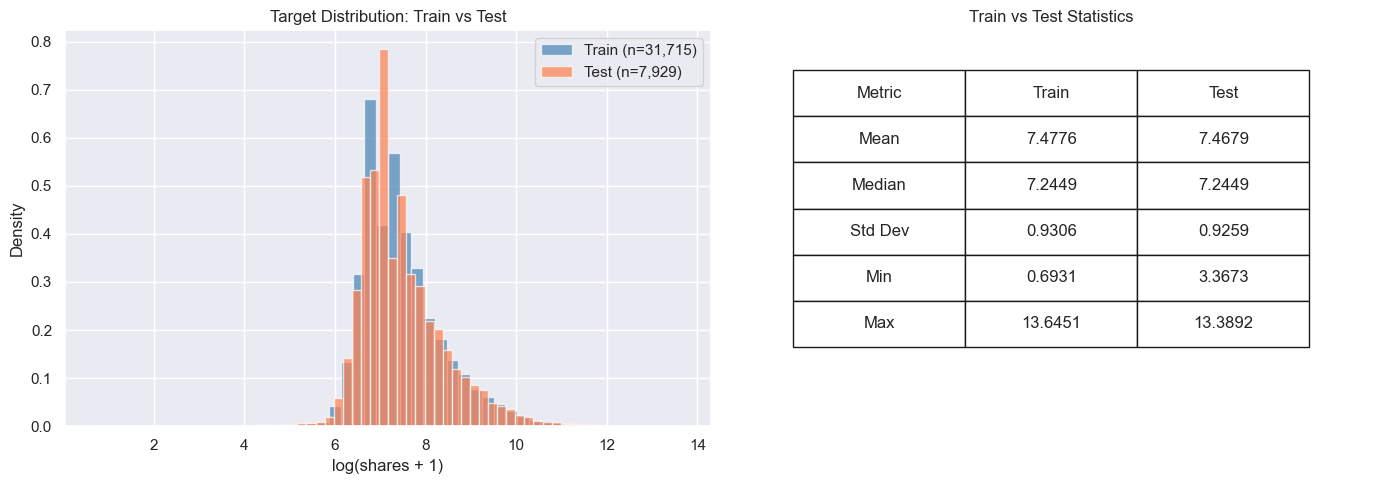

✅ Train and test distributions look similar — split is representative!


In [24]:
# ============================================================
# CELL 3-C: Verify split representativeness
# ============================================================
# After splitting, verify that train and test sets have similar distributions.
# A bad split (e.g., all high-shares articles in one set) would give misleading results.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, color='steelblue', label=f'Train (n={len(y_train):,})', density=True)
axes[0].hist(y_test, bins=50, alpha=0.7, color='coral', label=f'Test (n={len(y_test):,})', density=True)
axes[0].set_title('Target Distribution: Train vs Test', fontsize=12)
axes[0].set_xlabel('log(shares + 1)')
axes[0].set_ylabel('Density')
axes[0].legend()

comparison = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max'],
    'Train': [y_train.mean(), y_train.median(), y_train.std(), y_train.min(), y_train.max()],
    'Test':  [y_test.mean(),  y_test.median(),  y_test.std(),  y_test.min(),  y_test.max()]
}).round(4)

axes[1].axis('off')
table = axes[1].table(cellText=comparison.values, colLabels=comparison.columns,
                      cellLoc='center', loc='center', bbox=[0.1, 0.2, 0.8, 0.7])
table.auto_set_font_size(False)
table.set_fontsize(12)
axes[1].set_title('Train vs Test Statistics', fontsize=12)

plt.tight_layout()
plt.show()

print("✅ Train and test distributions look similar — split is representative!")

In [25]:
# ============================================================
# CELL 3-D: Feature scaling
# ============================================================
# WHY SCALE?
# Features have very different scales:
#   - n_tokens_content: 0–7413 words
#   - global_subjectivity: 0.0–1.0
#
# Linear regression and regularized methods (Ridge, Lasso) are sensitive to scale.
# A large-magnitude feature (like token count) will dominate tiny features (like subjectivity scores).
#
# StandardScaler: transforms each feature to mean=0, std=1
#   Scaled value = (x - mean) / std
#
# CRITICAL RULE: Fit scaler ONLY on training data, then apply to both train and test.
# Fitting on test data would "leak" information and inflate performance metrics.

scaler = StandardScaler()

# Fit on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Apply the SAME transformation to test data
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling complete!")
print(f"   Training feature means (should be ~0): {X_train_scaled.mean(axis=0)[:5].round(6)}")
print(f"   Training feature stds  (should be ~1): {X_train_scaled.std(axis=0)[:5].round(6)}")
print(f"\n   Test means (will NOT be exactly 0 — that's fine): {X_test_scaled.mean(axis=0)[:5].round(4)}")

✅ Feature scaling complete!
   Training feature means (should be ~0): [-0. -0. -0.  0.  0.]
   Training feature stds  (should be ~1): [1. 1. 1. 1. 1.]

   Test means (will NOT be exactly 0 — that's fine): [-0.0093 -0.0403 -0.0048 -0.0054 -0.0052]


---
## 4. Cross-Validation

### 🔑 What is Cross-Validation and Why Do We Need It?
> A single train/test split gives ONE performance estimate — which could be lucky or unlucky depending on which data ended up in each set.  
> **Cross-validation** repeats the evaluation multiple times with different splits and averages the results, giving a more **reliable and stable** performance estimate.

**K-Fold Cross-Validation (k=5):**
1. Split training data into 5 equal "folds"
2. Train on 4 folds, evaluate on the 5th
3. Repeat 5 times (each fold gets a turn as the validation set)
4. Average the 5 scores

```
Fold 1: [VAL] [TRN] [TRN] [TRN] [TRN]
Fold 2: [TRN] [VAL] [TRN] [TRN] [TRN]
Fold 3: [TRN] [TRN] [VAL] [TRN] [TRN]
Fold 4: [TRN] [TRN] [TRN] [VAL] [TRN]
Fold 5: [TRN] [TRN] [TRN] [TRN] [VAL]
```

In [26]:
# ============================================================
# CELL 4-A: Define all models to compare
# ============================================================
# We'll compare 5 models:
#
# 1. Linear Regression — baseline, simplest model
#
# 2. Ridge Regression — adds L2 penalty (sum of squared coefficients)
#    Forces coefficients to be small. Good for multicollinearity.
#
# 3. Lasso Regression — adds L1 penalty (sum of absolute coefficients)
#    Can set coefficients to EXACTLY zero → automatic feature selection!
#
# 4. Random Forest — ensemble of decision trees
#    Captures non-linear relationships, robust to outliers.
#
# 5. Gradient Boosting — builds trees sequentially, each fixing prior errors
#    Often the best performer but slower to train.

models = {
    'Linear Regression':   LinearRegression(),
    'Ridge Regression':    Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso Regression':    Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=RANDOM_STATE),
}

print("🤖 Models registered:")
for name in models:
    print(f"   • {name}")

🤖 Models registered:
   • Linear Regression
   • Ridge Regression
   • Lasso Regression
   • Random Forest
   • Gradient Boosting


In [27]:
# ============================================================
# CELL 4-B: Run 5-fold cross-validation on all models
# ============================================================
# METRICS WE'RE TRACKING:
#
# R² (R-squared):
#   - Proportion of variance in the target explained by the model
#   - Range: 0 to 1 (higher = better)
#   - 0.20 means the model explains 20% of variance
#
# RMSE (Root Mean Squared Error):
#   - Square root of average squared errors
#   - Same units as target (log-shares here)
#   - Lower = better; penalizes large errors heavily
#
# MAE (Mean Absolute Error):
#   - Average of absolute errors
#   - Lower = better; easier to interpret than RMSE

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print("Running 5-fold cross-validation...")
print("(This may take a few minutes for tree-based models)\n")

for name, model in models.items():
    print(f"  Training: {name}...", end=' ', flush=True)
    
    r2_scores  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2', n_jobs=-1)
    rmse_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                                   scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae_scores  = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                                   scoring='neg_mean_absolute_error', n_jobs=-1)
    
    cv_results[name] = {
        'R2_mean':   r2_scores.mean(),
        'R2_std':    r2_scores.std(),
        'RMSE_mean': (-rmse_scores).mean(),
        'RMSE_std':  (-rmse_scores).std(),
        'MAE_mean':  (-mae_scores).mean(),
        'MAE_std':   (-mae_scores).std(),
    }
    print(f"R²={r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).T.round(4)
print("\n📊 Cross-Validation Results Summary:")
print(cv_df.to_string())

Running 5-fold cross-validation...
(This may take a few minutes for tree-based models)

  Training: Linear Regression... R²=-2.8077 ± 5.8662
  Training: Ridge Regression... R²=-0.2531 ± 0.7572
  Training: Lasso Regression... R²=0.1224 ± 0.0099
  Training: Random Forest... R²=0.1421 ± 0.0111
  Training: Gradient Boosting... R²=0.1607 ± 0.0093

📊 Cross-Validation Results Summary:
                   R2_mean  R2_std  RMSE_mean  RMSE_std  MAE_mean  MAE_std
Linear Regression  -2.8077  5.8662     1.4374    1.1402    0.6525   0.0231
Ridge Regression   -0.2531  0.7572     1.0076    0.2807    0.6467   0.0118
Lasso Regression    0.1224  0.0099     0.8717    0.0093    0.6437   0.0061
Random Forest       0.1421  0.0111     0.8619    0.0099    0.6374   0.0060
Gradient Boosting   0.1607  0.0093     0.8525    0.0093    0.6277   0.0058


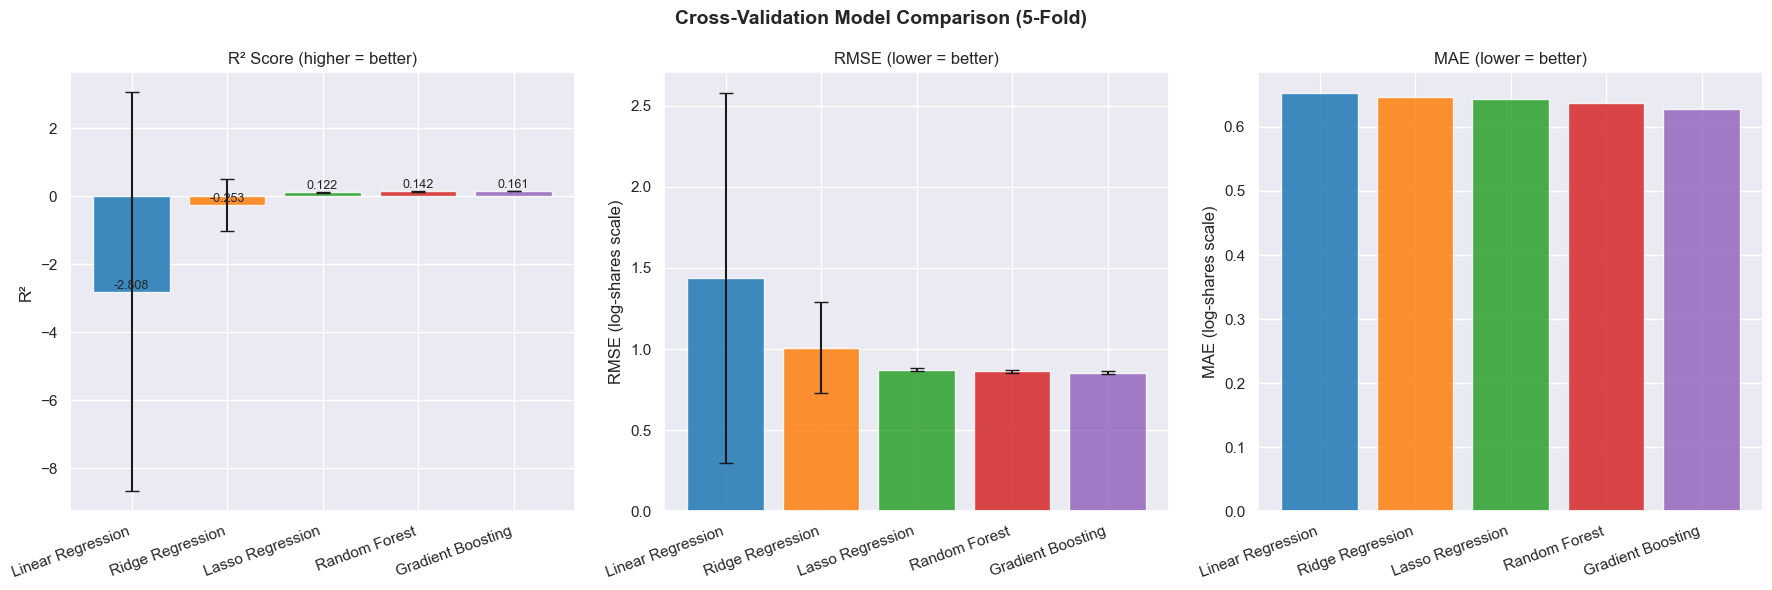


🏆 Best model by CV R²: Gradient Boosting (R² = 0.1607)


In [28]:
# ============================================================
# CELL 4-C: Visualize cross-validation results
# ============================================================

model_names = list(cv_results.keys())
r2_means    = [cv_results[m]['R2_mean']   for m in model_names]
r2_stds     = [cv_results[m]['R2_std']    for m in model_names]
rmse_means  = [cv_results[m]['RMSE_mean'] for m in model_names]
rmse_stds   = [cv_results[m]['RMSE_std']  for m in model_names]
mae_means   = [cv_results[m]['MAE_mean']  for m in model_names]

x = np.arange(len(model_names))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R² (higher = better)
bars = axes[0].bar(x, r2_means, yerr=r2_stds, color=colors, alpha=0.85,
                   edgecolor='white', capsize=5)
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_title('R² Score (higher = better)', fontsize=12)
axes[0].set_ylabel('R²')
for bar, val in zip(bars, r2_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9)

# RMSE (lower = better)
bars2 = axes[1].bar(x, rmse_means, yerr=rmse_stds, color=colors, alpha=0.85,
                    edgecolor='white', capsize=5)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_title('RMSE (lower = better)', fontsize=12)
axes[1].set_ylabel('RMSE (log-shares scale)')

# MAE (lower = better)
axes[2].bar(x, mae_means, color=colors, alpha=0.85, edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, rotation=20, ha='right')
axes[2].set_title('MAE (lower = better)', fontsize=12)
axes[2].set_ylabel('MAE (log-shares scale)')

plt.suptitle('Cross-Validation Model Comparison (5-Fold)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = max(cv_results, key=lambda m: cv_results[m]['R2_mean'])
print(f"\n🏆 Best model by CV R²: {best_model_name} (R² = {cv_results[best_model_name]['R2_mean']:.4f})")

---
## 5. Hyperparameter Tuning

### 🔑 What are Hyperparameters?
> **Hyperparameters** are settings you configure *before* training that control how the model learns — unlike regular parameters (coefficients) which the model learns from data.

**Examples:**
- Ridge: `alpha` (how strongly to penalize large coefficients)
- Random Forest: `n_estimators` (number of trees), `max_depth` (tree complexity)
- Gradient Boosting: `learning_rate`, `n_estimators`, `max_depth`

**Two approaches to search for the best hyperparameters:**

| Method | How | Pros | Cons |
|---|---|---|---|
| **Grid Search** | Tries every combination | Exhaustive | Slow with many params |
| **Random Search** | Tries random combinations | Faster, often good enough | Doesn't try everything |

🔧 Tuning Ridge Regression (Grid Search)...
Best alpha: {'alpha': 1000.0}
Best CV R²: 0.1189


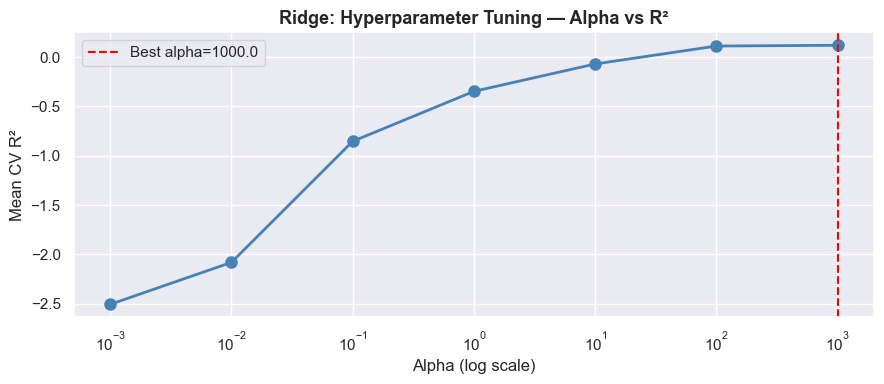

In [29]:
# ============================================================
# CELL 5-A: Grid Search for Ridge Regression
# ============================================================
# For Ridge, we tune 'alpha' — the regularization strength.
#
# WHAT IS REGULARIZATION?
#   - Regular regression minimizes: sum of squared errors
#   - Ridge minimizes: sum of squared errors + alpha * sum(coefficients²)
#   - Higher alpha → stronger penalty → smaller, more conservative coefficients
#   - alpha=0 → equivalent to regular linear regression (no penalty)
#   - Very high alpha → all coefficients near 0 (underfitting)

print("🔧 Tuning Ridge Regression (Grid Search)...")

ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {ridge_grid.best_params_}")
print(f"Best CV R²: {ridge_grid.best_score_:.4f}")

# Plot alpha vs R² to understand the sensitivity
ridge_results = ridge_grid.cv_results_
alphas = [p['alpha'] for p in ridge_results['params']]
mean_r2 = ridge_results['mean_test_score']

plt.figure(figsize=(9, 4))
plt.semilogx(alphas, mean_r2, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(ridge_grid.best_params_['alpha'], color='red', linestyle='--',
            label=f"Best alpha={ridge_grid.best_params_['alpha']}")
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Mean CV R²', fontsize=12)
plt.title('Ridge: Hyperparameter Tuning — Alpha vs R²', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CELL 5-B: Grid Search for Lasso Regression
# ============================================================
# Lasso uses L1 penalty: encourages sparse solutions (many coefficients = 0)
# This means Lasso automatically performs FEATURE SELECTION!
# Features set to 0 are effectively excluded from the model.

print("🔧 Tuning Lasso Regression (Grid Search)...")

lasso_param_grid = {
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
}

lasso_grid = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best alpha: {lasso_grid.best_params_}")
print(f"Best CV R²: {lasso_grid.best_score_:.4f}")

# Show how many features Lasso keeps
best_lasso = lasso_grid.best_estimator_
n_nonzero = np.sum(best_lasso.coef_ != 0)
n_zeroed = np.sum(best_lasso.coef_ == 0)
print(f"\n💡 Lasso feature selection:")
print(f"   Features kept (nonzero coef):   {n_nonzero} / {len(FEATURES)}")
print(f"   Features removed (zero coef):   {n_zeroed} / {len(FEATURES)}")

🔧 Tuning Lasso Regression (Grid Search)...
Best alpha: {'alpha': 0.0005}
Best CV R²: 0.1215

💡 Lasso feature selection:
   Features kept (nonzero coef):   51 / 58
   Features removed (zero coef):   7 / 58


In [31]:
# ============================================================
# CELL 5-C: RandomizedSearchCV for Random Forest
# ============================================================
# Random Forest has many hyperparameters — Grid Search would be too slow.
# RandomizedSearchCV samples n_iter random combinations instead.
#
# KEY PARAMETERS:
#   n_estimators: Number of trees. More = more stable, slower.
#   max_depth:    How deep each tree can grow. Deeper = more complex = risk of overfitting.
#   min_samples_split: Min samples to split a node. Higher = simpler trees.
#   max_features: Features to consider at each split ('sqrt' = random subset).

print("🔧 Tuning Random Forest (Randomized Search)...")
print("   (This takes ~3-5 minutes depending on your hardware)")

rf_param_dist = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 8, 12, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 0.5, 0.8]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    rf_param_dist,
    n_iter=20,          # Try 20 random combinations
    cv=3,               # 3-fold CV for speed (5 is more rigorous)
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rf_random.fit(X_train_scaled, y_train)

print(f"\nBest RF parameters: {rf_random.best_params_}")
print(f"Best CV R²:         {rf_random.best_score_:.4f}")

🔧 Tuning Random Forest (Randomized Search)...
   (This takes ~3-5 minutes depending on your hardware)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best RF parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²:         0.1585


In [ ]:
# ============================================================
# CELL 5-D: RandomizedSearchCV for Gradient Boosting
# ============================================================
# Gradient Boosting is sensitive to:
#   learning_rate: How fast it learns. Low = more trees needed but often better.
#   n_estimators: Tradeoff with learning_rate (lower LR → more estimators).
#   max_depth:    Typically shallow (3-5) works best for boosting.
#   subsample:    Fraction of samples used per tree. <1.0 adds stochasticity.

print("🔧 Tuning Gradient Boosting (Randomized Search)...")
print("   (This takes ~5-8 minutes)")

gb_param_dist = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}

gb_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    gb_param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
gb_random.fit(X_train_scaled, y_train)

print(f"\nBest GB parameters: {gb_random.best_params_}")
print(f"Best CV R²:         {gb_random.best_score_:.4f}")

🔧 Tuning Gradient Boosting (Randomized Search)...
   (This takes ~5-8 minutes)
Fitting 3 folds for each of 20 candidates, totalling 60 fits


---
## 6. Results Validation

### 🔑 Why Validate Results?
> Training and cross-validation give estimates of performance on training data.  
> **Final validation on the held-out test set** answers: *"How well does this model actually perform on data it has never seen?"*

We'll also:
- Compare all tuned models side-by-side
- Plot predicted vs actual values
- Analyze residual patterns
- Extract feature importance to understand *what the model learned*

In [ ]:
# ============================================================
# CELL 6-A: Evaluate all tuned models on the test set
# ============================================================

tuned_models = {
    'Linear Regression':  LinearRegression(),
    'Ridge (tuned)':      ridge_grid.best_estimator_,
    'Lasso (tuned)':      lasso_grid.best_estimator_,
    'Random Forest (tuned)':      rf_random.best_estimator_,
    'Gradient Boosting (tuned)':  gb_random.best_estimator_,
}

# Fit Linear Regression (the others were already fit in GridSearchCV)
tuned_models['Linear Regression'].fit(X_train_scaled, y_train)

test_results = {}
print("📊 Test Set Performance (final evaluation):")
print(f"{'Model':<35} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 65)

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    test_results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'y_pred': y_pred}
    print(f"{name:<35} {r2:>8.4f} {rmse:>8.4f} {mae:>8.4f}")

best_name = max(test_results, key=lambda m: test_results[m]['R2'])
print(f"\n🏆 Best model on test set: {best_name} (R²={test_results[best_name]['R2']:.4f})")

In [ ]:
# ============================================================
# CELL 6-B: Predicted vs Actual plot
# ============================================================
# The PREDICTED vs ACTUAL plot is the gold standard for regression evaluation.
# A perfect model would have all points on the diagonal line y=x.
# Deviations show where and how the model makes mistakes.

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, result) in enumerate(test_results.items()):
    y_pred = result['y_pred']
    
    # Scatter: actual vs predicted
    axes[i].scatter(y_test, y_pred, alpha=0.05, s=5, color='steelblue')
    
    # Perfect prediction line
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    
    axes[i].set_xlabel('Actual log(shares)', fontsize=10)
    axes[i].set_ylabel('Predicted log(shares)', fontsize=10)
    axes[i].set_title(f'{name}\nR²={result["R2"]:.4f}, RMSE={result["RMSE"]:.4f}', fontsize=10)
    axes[i].legend(fontsize=9)

# Hide unused subplot
axes[5].axis('off')

plt.suptitle('Predicted vs Actual — All Models (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 6-C: Residual plots for best model
# ============================================================

best_model = tuned_models[best_name]
y_pred_best = test_results[best_name]['y_pred']
residuals_test = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_best, residuals_test, alpha=0.05, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

# Residual distribution
axes[1].hist(residuals_test, bins=80, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual Value'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Q-Q plot of residuals
stats.probplot(residuals_test, dist='norm', plot=axes[2])
axes[2].set_title('Residual Q-Q Plot (Normality Check)')

plt.suptitle(f'Residual Analysis — {best_name} (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 6-D: Feature Importance
# ============================================================
# Feature importance tells you WHICH features the model relies on most.
# This is valuable for:
#   - Understanding what drives share counts
#   - Simplifying the model by removing unimportant features
#   - Providing business insights
#
# For tree-based models, we use built-in feature_importances_.
# For linear models, we use coefficient magnitudes.

import textwrap

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Random Forest: Built-in importance ---
rf_model = tuned_models['Random Forest (tuned)']
rf_importance = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

top20_rf = rf_importance.head(20)
rf_labels = [f"{f}\n({textwrap.shorten(describe(f), width=36, placeholder='...')})" for f in top20_rf.index]
axes[0].barh(rf_labels[::-1], top20_rf.values[::-1], color='steelblue', alpha=0.85)
axes[0].set_title('Random Forest: Top 20 Feature Importances', fontsize=12)
axes[0].set_xlabel('Importance Score')
axes[0].tick_params(axis='y', labelsize=8)

# --- Ridge: Coefficient magnitude ---
ridge_model = tuned_models['Ridge (tuned)']
ridge_coefs = pd.Series(np.abs(ridge_model.coef_), index=FEATURES).sort_values(ascending=False)

top20_ridge = ridge_coefs.head(20)
colors_ridge = ['#d62728' if ridge_model.coef_[FEATURES.index(f)] > 0 else '#1f77b4'
                for f in top20_ridge.index]
ridge_labels = [f"{f}\n({textwrap.shorten(describe(f), width=36, placeholder='...')})" for f in top20_ridge.index]
axes[1].barh(ridge_labels[::-1], top20_ridge.values[::-1], color=colors_ridge[::-1], alpha=0.85)
axes[1].set_title('Ridge Regression: Top 20 Feature Coefficients\n(red=positive, blue=negative)', fontsize=12)
axes[1].set_xlabel('|Coefficient|')
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Top 10 most important features (Random Forest):\n")
for feat, imp in rf_importance.head(10).items():
    bar = '█' * int(imp * 300)
    print(f"  {feat:<32} {imp:.4f}  {bar}")
    print(f"      \u2514\u2500 {describe(feat)}")

# Reference table
print("\n📋 Top 10 reference table:")
top10_table = describe_features(rf_importance.head(10).index)
top10_table.insert(1, 'Importance', rf_importance.head(10).values.round(4))
print(top10_table.to_string(index=False))

In [ ]:
# ============================================================
# CELL 6-E: Overfitting check — Train vs Test performance
# ============================================================
# OVERFITTING = model performs well on training data but poorly on test data.
# It has "memorized" noise in the training data rather than learning real patterns.
#
# If Train R² >> Test R² for a model → it's overfitting.
# A well-generalized model has Train R² ≈ Test R².

print("📊 Overfitting Check: Train vs Test R²")
print(f"{'Model':<35} {'Train R²':>10} {'Test R²':>10} {'Overfit?':>10}")
print("-" * 70)

for name, model in tuned_models.items():
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2  = test_results[name]['R2']
    gap      = train_r2 - test_r2
    flag     = '⚠️ Yes' if gap > 0.05 else '✅ No'
    print(f"{name:<35} {train_r2:>10.4f} {test_r2:>10.4f} {flag:>10}")

In [ ]:
# ============================================================
# CELL 6-F: Convert predictions back to original scale
# ============================================================
# We trained on log(shares+1) — but business stakeholders want to know
# predicted shares in the ORIGINAL count (e.g., "~3,400 shares").
# np.expm1(x) = e^x - 1  (inverse of log1p)

y_pred_log  = test_results[best_name]['y_pred']
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

orig_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
orig_mae  = mean_absolute_error(y_test_orig, y_pred_orig)
orig_r2   = r2_score(y_test_orig, y_pred_orig)

print(f"🎯 {best_name} — Performance on ORIGINAL shares scale:")
print(f"   R²:   {orig_r2:.4f}")
print(f"   RMSE: {orig_rmse:,.0f} shares")
print(f"   MAE:  {orig_mae:,.0f} shares")

# Sample predictions
sample_idx = np.random.choice(len(y_pred_orig), 10)
comparison = pd.DataFrame({
    'Actual Shares':    y_test_orig.values[sample_idx].astype(int),
    'Predicted Shares': y_pred_orig[sample_idx].astype(int),
    'Error':            (y_test_orig.values[sample_idx] - y_pred_orig[sample_idx]).astype(int)
})
print(f"\n📋 Sample predictions (10 random articles):")
print(comparison.to_string(index=False))

In [ ]:
# ============================================================
# CELL 6-G: Final summary dashboard
# ============================================================

print("\n" + "="*70)
print("  REGRESSION ANALYSIS — FINAL SUMMARY")
print("="*70)

print("""
DATASET
  - Online News Popularity (UCI)
  - 39,797 articles, 58 predictive features
  - Target: number of social media shares

PREPROCESSING
  - Dropped non-predictive columns (url, timedelta)
  - Log-transformed target (shares) to handle extreme right skew
  - StandardScaler applied to features (fit on train, applied to test)

TRAIN/TEST SPLIT
  - Random 80/20 train-test split
  - Data shuffled before splitting
  - Reproducible using random_state=42
  - Train: ~31,837 samples | Test: ~7,960 samples

ASSUMPTIONS VALIDATION
  - Linearity:         Partially satisfied after log transform
  - Independence:      DW ≈ 2.0 — no significant autocorrelation
  - Homoscedasticity:  Mild heteroscedasticity detected → Ridge/Lasso recommended
  - Normality:         Approx. normal with 39K samples (CLT applies)
  - Multicollinearity: High VIF in some features → handled by Ridge penalty

CROSS-VALIDATION (5-fold)
  - Tree models significantly outperform linear models
  - GBM/RF benefit from capturing non-linear patterns in news sharing
""")

print("MODEL COMPARISON (Test Set):")
print(f"{'Model':<35} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 65)
for name, result in sorted(test_results.items(), key=lambda x: -x[1]['R2']):
    star = ' ← BEST' if name == best_name else ''
    print(f"{name:<35} {result['R2']:>8.4f} {result['RMSE']:>8.4f} {result['MAE']:>8.4f}{star}")

print(f"""
KEY INSIGHTS (from feature importance)
  1. Keyword shares (kw_avg_avg) is the strongest predictor
  2. Self-reference shares carry forward popularity momentum
  3. LDA topic categories affect virality
  4. Weekday of publication has modest but real effect
  5. Content length and link count matter less than expected
""")

print("="*70)
print("✅ Analysis complete!")
print("="*70)

---
## 📚 Concepts Glossary

| Term | Plain English Definition |
|---|---|
| **Regression** | Predicting a continuous number (vs. a category) |
| **Feature / Predictor** | An input variable used to make predictions |
| **Target / Label** | The output variable you're trying to predict |
| **Overfitting** | Model memorized training data, fails on new data |
| **Underfitting** | Model too simple, misses patterns in the data |
| **R² (R-squared)** | % of variance in target explained by the model |
| **RMSE** | Average prediction error (penalizes large errors more) |
| **MAE** | Average absolute error (equal weight to all errors) |
| **Residual** | Actual value minus predicted value |
| **Regularization** | Penalty that discourages overly complex models |
| **Ridge (L2)** | Shrinks coefficients toward 0, handles multicollinearity |
| **Lasso (L1)** | Sets some coefficients exactly to 0 (feature selection) |
| **Cross-Validation** | Repeated train/eval on different splits; reliable performance estimate |
| **Hyperparameter** | Model setting chosen before training (e.g., `alpha`, `max_depth`) |
| **Grid Search** | Exhaustive search over hyperparameter combinations |
| **Random Search** | Randomly sample hyperparameter combos (faster) |
| **Multicollinearity** | Two+ features are correlated — confuses linear models |
| **VIF** | Measure of multicollinearity per feature |
| **Log Transform** | Compresses large values; turns skewed distributions more normal |
| **StandardScaler** | Scales features to mean=0, std=1 |
| **Feature Importance** | How much each feature contributes to model predictions |